In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib import patches
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
from sunpy.coordinates.spice import get_rotation_matrix
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from streamtracer import StreamTracer, VectorGrid
from extrapolater import PotentialField
from helpers import from_local

import h5py 
import dask.array as da 
from ndcube import NDCube

import pyvista as pv

In [3]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [4]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
def read_vtk_to_numpy(filename):
    """
    Read VTK file and extract data as numpy arrays
    
    Parameters:
    filename: path to VTK file
    
    Returns:
    dict containing grid info and data arrays
    """
    # Read the VTK file
    mesh = pv.read(filename)
    
    # Get grid dimensions and spacing
    dimensions = mesh.dimensions
    spacing = mesh.spacing
    origin = mesh.origin
    
    print(f"Grid dimensions: {dimensions}")
    print(f"Grid spacing: {spacing}")
    print(f"Grid origin: {origin}")
    print(f"Available arrays: {list(mesh.array_names)}")
    
    # Extract all data arrays
    data_arrays = {}
    
    # Point data (most common)
    for name in mesh.point_data.keys():
        array = mesh.point_data[name]
        print(f"Point data '{name}': shape {array.shape}")
        data_arrays[f"point_{name}"] = array
    
    # Cell data
    for name in mesh.cell_data.keys():
        array = mesh.cell_data[name]
        print(f"Cell data '{name}': shape {array.shape}")
        data_arrays[f"cell_{name}"] = array
    
    return {
        'dimensions': dimensions,
        'spacing': spacing,
        'origin': origin,
        'data': data_arrays,
        'mesh': mesh  # Keep reference to original mesh
    }

def reshape_to_3d_grid(flat_array, dimensions):
    """
    Reshape flat array back to 3D grid format
    
    Parameters:
    flat_array: 1D or 2D numpy array from VTK
    dimensions: tuple of (nx, ny, nz)
    
    Returns:
    reshaped array
    """
    nx, ny, nz = dimensions
    
    if flat_array.ndim == 1:
        # Scalar field
        return flat_array.reshape((nz, ny, nx)).transpose(2, 1, 0)
    elif flat_array.ndim == 2 and flat_array.shape[1] == 3:
        # Vector field
        reshaped = flat_array.reshape((nz, ny, nx, 3)).transpose(2, 1, 0, 3)
        return reshaped
    else:
        # General case
        return flat_array.reshape((nz, ny, nx, -1)).transpose(2, 1, 0, 3)

def read_vector_field_from_vtk(filename, vector_name="B"):
    """
    Read vector field from VTK file and return as (nx, ny, nz, 3) array
    
    Parameters:
    filename: path to VTK file
    vector_name: name of the vector field in the VTK file
    
    Returns:
    numpy array of shape (nx, ny, nz, 3)
    """
    vtk_data = read_vtk_to_numpy(filename)
    
    # Look for the vector field
    vector_key = f"point_{vector_name}"
    if vector_key not in vtk_data['data']:
        available = [k for k in vtk_data['data'].keys() if 'point_' in k]
        raise ValueError(f"Vector field '{vector_name}' not found. Available: {available}")
    
    vectors_flat = vtk_data['data'][vector_key]
    dimensions = vtk_data['dimensions']
    
    # Reshape to 3D grid
    vector_array = reshape_to_3d_grid(vectors_flat, dimensions)
    
    return vector_array, vtk_data

In [6]:
bxyz, info = read_vector_field_from_vtk("/cluster/home/zhuyin/work/cfit_work_dir/20221024_1841_SOTSP_fullfov/bxyz_B_0002_0032.vtk", "B")

Grid dimensions: (960, 540, 540)
Grid spacing: (1.0, 1.0, 1.0)
Grid origin: (0.0, 0.0, 0.0)
Available arrays: ['B']
Point data 'B': shape (279936000, 3)


In [7]:
bx, by, bz = bxyz[:,:,:,0], bxyz[:,:,:,1], bxyz[:,:,:,2]

In [8]:
x_arr = np.arange(bx.shape[0])
y_arr = np.arange(bx.shape[1])
z_arr = np.arange(bx.shape[2])

field_grid = VectorGrid(bxyz, grid_coords=[x_arr, y_arr, z_arr])

In [31]:
seeds = np.array([[ii, jj, 0] for ii in np.linspace(420, 420+140, 24)\
                    for jj in np.linspace(260, 260+120, 24)])

nsteps = 10000
step_size = 0.02
tracer = StreamTracer(nsteps, step_size)
tracer.trace(seeds, field_grid)

In [32]:
sotsp_br_map_hgs_0 = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")

In [33]:
def get_loop_length(fline):
    s = np.linalg.norm(np.diff(fline, axis=0), axis=1).cumsum()
    try:
        return s[-1]
    except:
        return 0

In [34]:
streamlines_hgs = []

pixel_scale = 0.23712652199468398

for line in tracer.xs[:]:
    # if line[-1,2] < 500:
        # if get_loop_length(line) < 50/pixel_scale:
    line_hgs = sotsp_br_map_hgs_0.wcs.pixel_to_world(line[:,0], line[:,1])
    line_hgs = SkyCoord(lon=line_hgs.lon, lat=line_hgs.lat, radius=line[:,2]*pixel_scale*u.Mm + 695700*u.km,
                        frame=line_hgs.frame)

    streamlines_hgs.append(line_hgs)

(-0.5, 3839.5, -0.5, 3839.5)

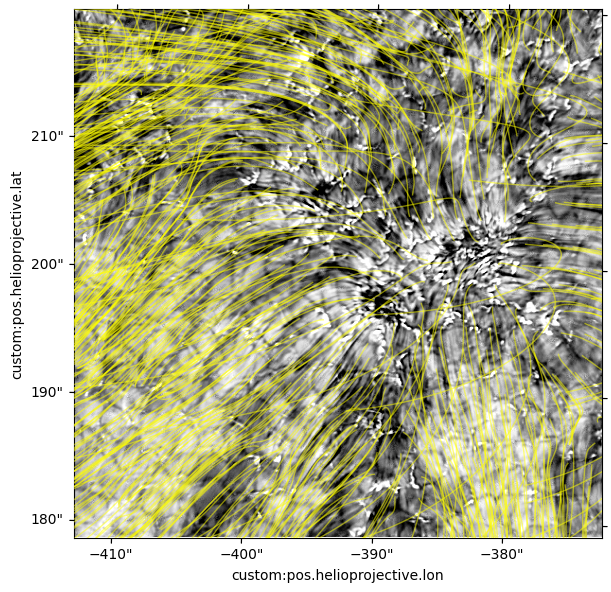

In [35]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none")

ax_lim = ax.axis()

with propagate_with_solar_surface():
    for fline in streamlines_hgs[:]: 
            ax.plot_coord(fline, color="#FFFF00", alpha=0.5, lw=1)

ax.axis(ax_lim)

In [36]:
def colored_line_with_alpha(x, y, c, ax, norm_color, norm_alpha, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    cmap = plt.get_cmap(default_kwargs.pop("cmap", "plasma"))
    color_rgb = cmap(norm_color(c))
    color_rgb[:,-1] = 1 - norm_alpha(c)*0.9

    lc = LineCollection(segments, colors=color_rgb, **default_kwargs)
    # lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

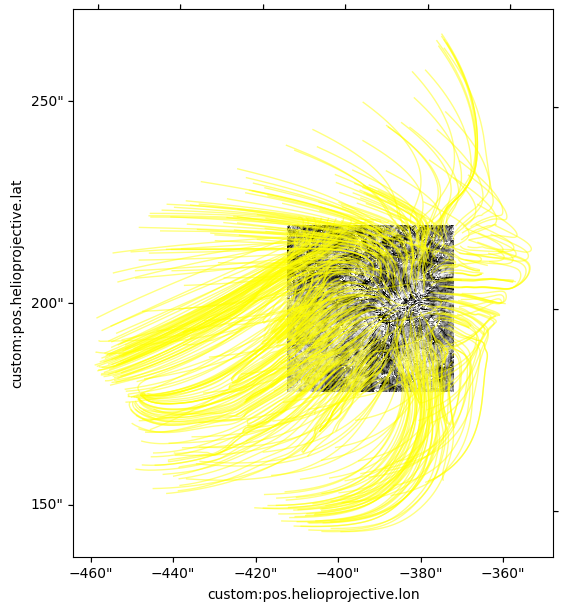

In [37]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none")

ax_lim = ax.axis()

with propagate_with_solar_surface():
    for fline in streamlines_hgs[:]:
        # ax.plot_coord(fline[0], color="red", alpha=0.3, lw=2, marker="o")
        ax.plot_coord(fline, color="#FFFF00", alpha=0.5, lw=1)

# ax.axis(ax_lim)

In [38]:
fline_vbi_pixel = []

for fline in streamlines_hgs[:]:
    with propagate_with_solar_surface():
        fline_pixel_x, fline_pixel_y = dkist_vbi_target_cube_crop.wcs.world_to_pixel(fline)
    fline_vbi_pixel.append([fline_pixel_x, fline_pixel_y, fline.radius.to_value(u.Mm) - 695.7])


(-0.5, 3839.5, -0.5, 3839.5)

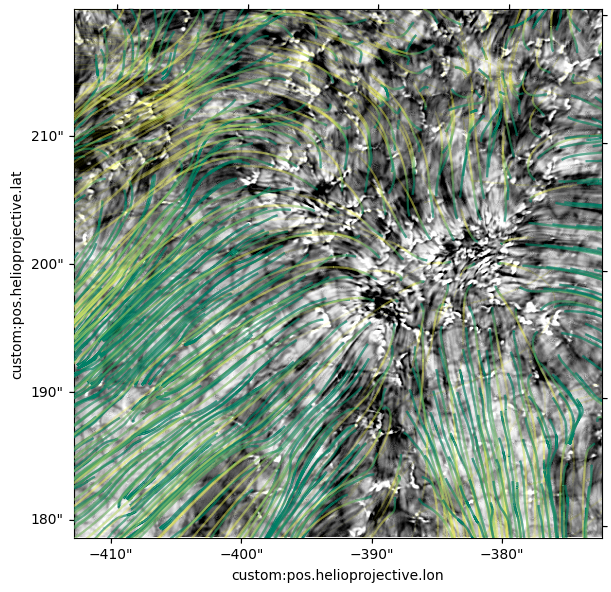

In [39]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none")

ax_lim = ax.axis()

for fline in fline_vbi_pixel[:]:
        colored_line_with_alpha(fline[0], fline[1], fline[2], ax, cmap="summer",
        norm_color=ImageNormalize(vmin=0,vmax=2, clip=True),
        norm_alpha=ImageNormalize(vmin=0,vmax=5, clip=True),
        lw=1.5)

ax.axis(ax_lim)

In [40]:
aia_map = sunpy.map.Map("../../data/pid_1_123_aux/AIA/171/aia.lev1_euv_12s.2022-10-24T192003Z.171.image.fits")

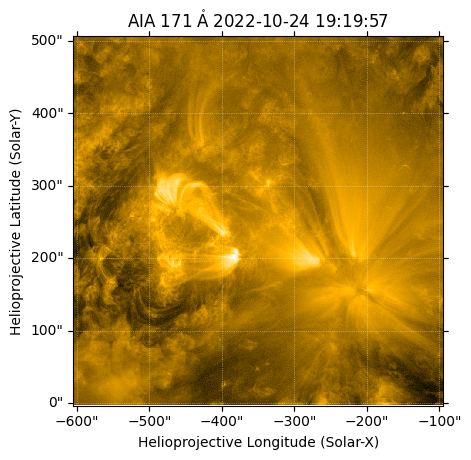

In [41]:
aia_map.plot()